## ATSEviz: Visualizing Alternative Splicing Events
This notebook demonstrates how to use the ATSEviz module from LeafletFA-utils to visualize alternative splicing events.

In [1]:
# Import necessary libraries
import pandas as pd
import os
import sys
import pandas as pd
import numpy as np
from typing import List, Set

# Alternatively, you can directly specify the path
module_path = "/gpfs/commons/home/kisaev/LeafletFA-utils"

# Add path if not already in sys.path
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Now you should be able to import from leafletfa_utils
from leafletfa_utils.atsemapper.main import run_atsemapper
from leafletfa_utils.atseviz.main import *
from leafletfa_utils.atsemapper.genome_utils import JunctionAnalyzer, GenomeDB # type: ignore

# Check that imports worked
print("Imports successful!")

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Imports successful!


In [2]:
# db_file = "/gpfs/commons/home/kisaev/LeafletFA-utils/examples/LeafletFA_ATSE_mapper_output_20250401_150841/annotation.db"

# get human db file 
db_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/hg38_stella_gtf"
db = gffutils.FeatureDB(db_file, keep_order=True)

In [3]:
# Load real ATSEs from human foundation dataset using Stella's GTF file
p = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/stella_gtf/TMS_atse_file_unanno_also_2025-05-11_06-23-05.txt.gz", sep="\t")

In [4]:
# Visualize random ATSEs
atse_event = p.sample(1)["event_id"].values[0]
print(f"The atse event is: {atse_event}")

# Create a copy of the subset to avoid SettingWithCopyWarning
juncs = p[p["event_id"] == atse_event].copy()
print(f"The number of junctions here is: {len(juncs)}")

# Use .loc to set values
juncs.loc[:, "usage_ratio"] = juncs["total_score"] / juncs["total_score"].sum()
juncs.loc[:, "Cluster"] = juncs["event_id"]

# Now convert junction IDs
splice_junctions = convert_junction_ids(juncs)
splice_junctions

The atse event is: ENSG00000131591.18_atse_1
The number of junctions here is: 24


[{'chrom': 'chr1',
  'start': 1115075,
  'end': 1116059,
  'name': 'junction_146340',
  'strand': '-',
  'usage_ratio': 0.008734939759036145,
  'gene_id': 'ENSG00000131591.18',
  'gene_name': nan},
 {'chrom': 'chr1',
  'start': 1092103,
  'end': 1116059,
  'name': 'junction_146341',
  'strand': '-',
  'usage_ratio': 0.5110692771084338,
  'gene_id': 'ENSG00000131591.18',
  'gene_name': nan},
 {'chrom': 'chr1',
  'start': 1106049,
  'end': 1116059,
  'name': 'junction_146342',
  'strand': '-',
  'usage_ratio': 0.02131024096385542,
  'gene_id': 'ENSG00000131591.18',
  'gene_name': nan},
 {'chrom': 'chr1',
  'start': 1096611,
  'end': 1116059,
  'name': 'junction_146343',
  'strand': '-',
  'usage_ratio': 0.006475903614457832,
  'gene_id': 'ENSG00000131591.18',
  'gene_name': nan},
 {'chrom': 'chr1',
  'start': 1095124,
  'end': 1116059,
  'name': 'junction_146344',
  'strand': '-',
  'usage_ratio': 0.04382530120481928,
  'gene_id': 'ENSG00000131591.18',
  'gene_name': nan},
 {'chrom': 'ch

In [5]:
juncs

,event_id,gene_id,gene_name,gene_types,num_junctions,event_type,chromosome,strand,atse_start,atse_end,...,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif,donor_seq,acceptor_seq,position_off_5_prime,position_off_3_prime,usage_ratio,Cluster
146339,ENSG00000131591.18_atse_1,ENSG00000131591.18,NaN,NaN,24,complex,chr1,-,1092103,1116059,...,0.8345,8126,139,GT-AG,GT,AG,1.0,0.0,0.008735,ENSG00000131591.18_atse_1
146340,ENSG00000131591.18_atse_1,ENSG00000131591.18,NaN,NaN,24,complex,chr1,-,1092103,1116059,...,0.6774,8126,10019,GT-AG,GT,AG,1.0,0.0,0.511069,ENSG00000131591.18_atse_1
146341,ENSG00000131591.18_atse_1,ENSG00000131591.18,NaN,NaN,24,complex,chr1,-,1092103,1116059,...,0.2030,8126,1394,GT-AG,GT,AG,1.0,0.0,0.021310,ENSG00000131591.18_atse_1
146342,ENSG00000131591.18_atse_1,ENSG00000131591.18,NaN,NaN,24,complex,chr1,-,1092103,1116059,...,0.0911,8126,944,GT-AG,GT,AG,1.0,NaN,0.006476,ENSG00000131591.18_atse_1
146343,ENSG00000131591.18_atse_1,ENSG00000131591.18,NaN,NaN,24,complex,chr1,-,1092103,1116059,...,0.6445,8126,903,GT-AG,GT,AG,1.0,NaN,0.043825,ENSG00000131591.18_atse_1
146344,ENSG00000131591.18_atse_1,ENSG00000131591.18,NaN,NaN,24,complex,chr1,-,1092103,1116059,...,1.0000,139,23,GT-AG,GT,AG,NaN,0.0,0.001732,ENSG00000131591.18_atse_1
146345,ENSG00000131591.18_atse_1,ENSG00000131591.18,NaN,NaN,24,complex,chr1,-,1092103,1116059,...,1.0000,10019,120,GT-AG,GT,AG,NaN,0.0,0.009036,ENSG00000131591.18_atse_1
146346,ENSG00000131591.18_atse_1,ENSG00000131591.18,NaN,NaN,24,complex,chr1,-,1092103,1116059,...,1.0000,10019,536,GT-AG,GT,AG,NaN,0.0,0.040361,ENSG00000131591.18_atse_1
146347,ENSG00000131591.18_atse_1,ENSG00000131591.18,NaN,NaN,24,complex,chr1,-,1092103,1116059,...,0.5102,10019,2636,GT-AG,GT,AG,1.0,0.0,0.101280,ENSG00000131591.18_atse_1
146348,ENSG00000131591.18_atse_1,ENSG00000131591.18,NaN,NaN,24,complex,chr1,-,1092103,1116059,...,1.0000,10019,134,GT-AG,GT,AG,NaN,0.0,0.010090,ENSG00000131591.18_atse_1


Found 14 unique transcripts
Plot saved to test.pdf!


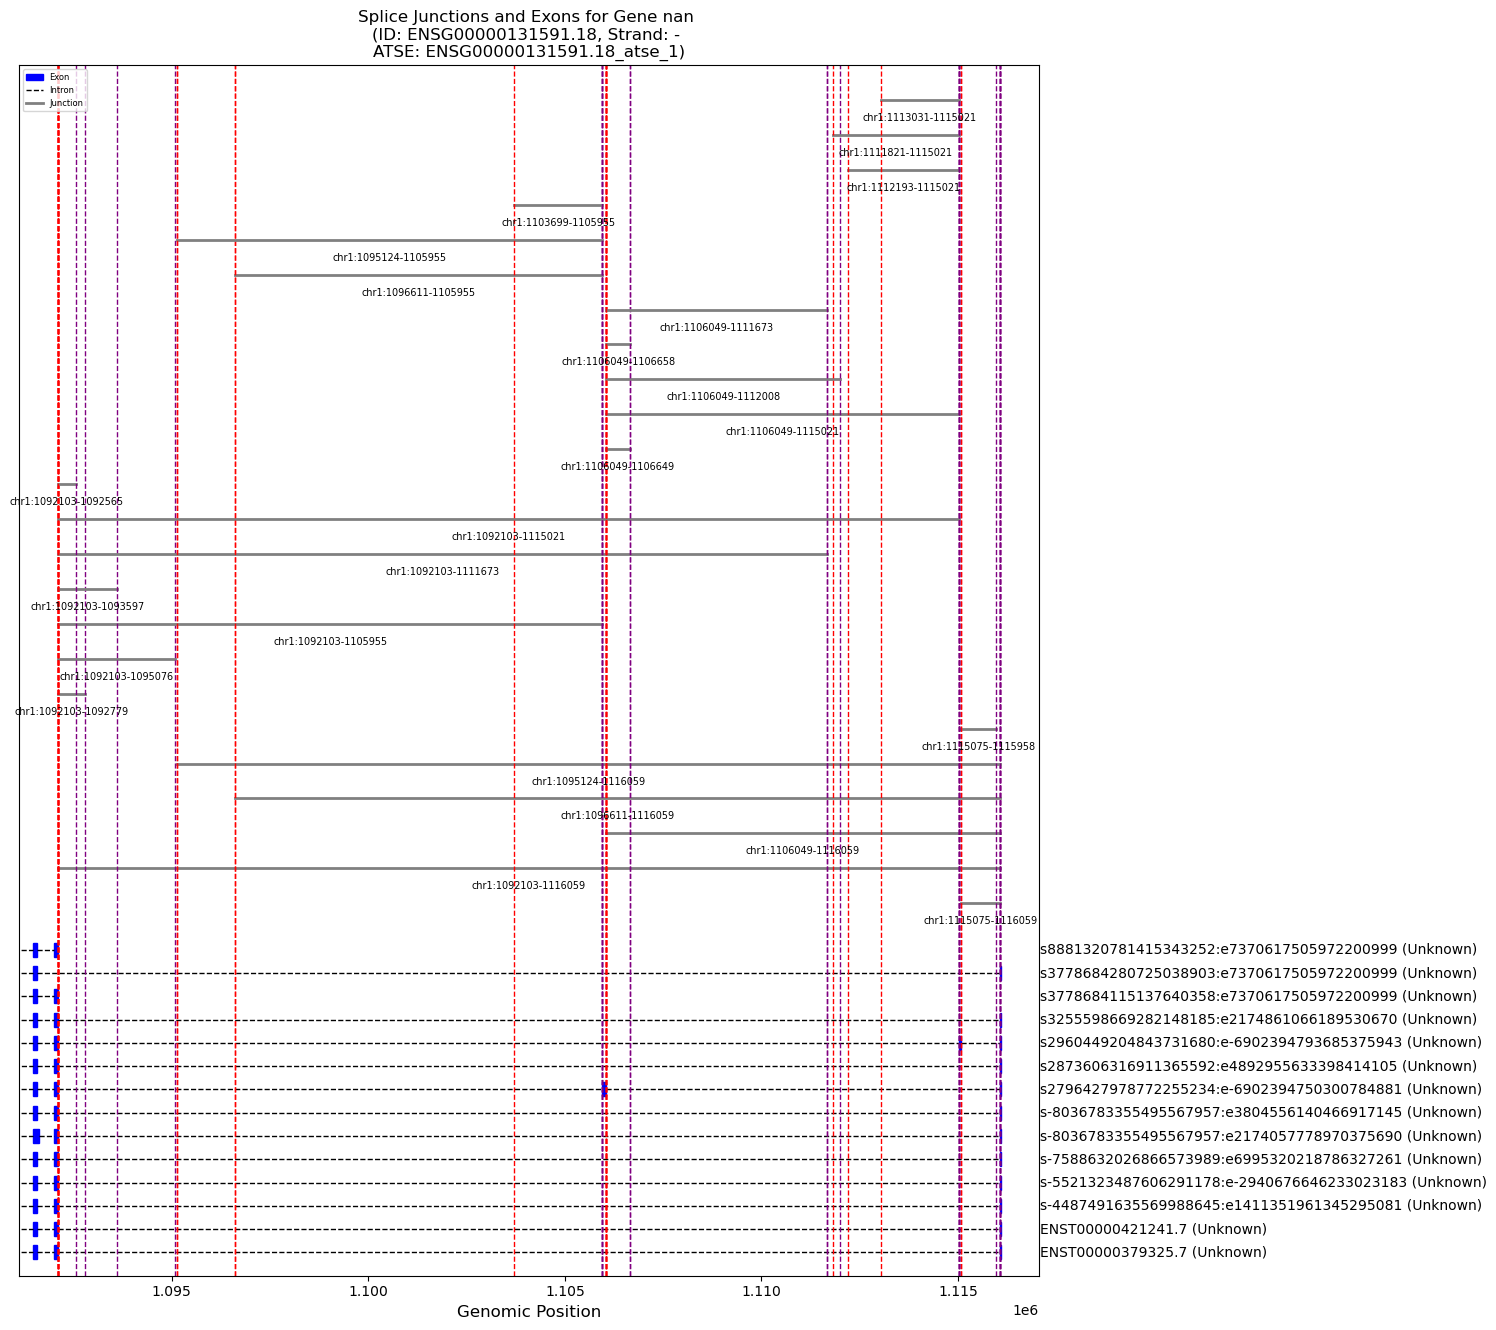

In [6]:
# Example usage:
unique_transcripts = extract_unique_transcripts(juncs)
print(f"Found {len(unique_transcripts)} unique transcripts")

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = fetch_transcripts_and_annotations(db, unique_transcripts)

# gene id
gene_id = p[p["event_id"] == atse_event]["gene_id"].iloc[1]

# From trancsript data get transcript_id to transcript_name to transcript_type mapping
conversions = {}
for t in transcript_data.keys():
    transcript_id = transcript_data[t]["transcript_id"]
    transcript_name = transcript_data[t]["transcript_name"]
    transcript_type = transcript_data[t]["transcript_type"]
    conversions[transcript_id] = {
        "transcript_name": transcript_name,
        "transcript_type": transcript_type, 
        "transcript_id": transcript_id
    } 

# convert to dataframe 
conversions_df = pd.DataFrame.from_dict(conversions, orient='index')

# Plot the junctions/transcripts involved in the ATSE 
region_start, region_end = determine_region_boundaries(splice_junctions)
plot_exons_and_junctions(db, atse_event, transcript_data, splice_junctions, region_start, region_end, 
                         base_width=15, trans_height=0.8, show_usage=False, 
                         show_junc_lines=True, filename="test.pdf")

# TO-DO:
# - Return plot as a plot object that users can add additional things to... matplotlib object? ax... concatenate... 
# - Feed in OG Leafcutter Intron Clusters... via intron cluster table... 
# - Feed in the Junction by Sample Table as input to junction annoation... BED file with extra columns... 
# - Similar to isoform plots, implement the intron scaling thing
# - VIsulize multiple ATSEs per gene wuld be nice 
# - Test on BigBrain bulk RNA-seq files 
# - Test on EasySci junctions 
# - sQTLs or other SNPs would be nice to visualize... 

In [ ]:
juncs.iloc[0]["perfect_match_3_prime"]

In [ ]:
juncs.iloc[1]["junction_id"]

In [ ]:
juncs.iloc[1]["perfect_match_3_prime"]